VARIAZIONI DI VAE: BETA-VAE, CVAE, e VQ-VAE

Queste 3 varianti del VAE classico, nascono tutte da un limite diverso. 
Le varianti cambiano il modo in cui gestiscono lo spazio latente o il controllo sulla generazione.

Come facciamo a passare da una macchina che genera a caso, ad una che genera con intenzione?
Vediamo l'evoluzione della VAE
vediamo: - come districare i concetti nello spazio latente - come dare oridini precisi al nostro generatore - come trasformare le nuvole di probabilità in mattoni digitali discreti.

- Beta-VAE: la ricerca del disentanglemente attraverso la pesatura della KL, ovvero la capacità di separare i fattori di variazione.
- Conditional VAE (CVAE): impariamo a guidare la generazione tramite etichette di classe specifiche.
- Vector Quantized VAE (VQ-VAE): La discretizzazione dello spazio latente. Abbandona il continuo per abbracciare il discreto. Aprendo la strada ai nuovi modelli

** Beta-VAE **

Come sapariamo i concetti che la rete tende a mescolare.

E' il più semplice da capire perchè parte proprio dal VAE classico.
La Loss diventa:
Loss = Reconstruction + beta + KL
nel VAE classico beta=1
nel Beta-VAE beta>1
questo per dare più importanza alla regolarizzazione del latent space.
Esempio 
se beta=4 la KL pesa 4 volte di più rispetto al KL del VAE classico.
L'obbiettivo principale del Beta-VAE non è necessarimente generare immagini più belle, è ottenere uno spazio latente più strutturato e possibilmente più disentangled.
Vogliamo che ogni asse del nostro spazio latente, controlli un solo attributo visico.
Disentanglement significa che le diverse caratteristiche del dato rappresentate in modo il più possibile separato nelle diverse dimensioni dello spazio latente. Quindi cercare di separare fattori diversi
Esempio:
immagini di volti
z1 -> orientamento testo
z2 -> sorriso
z3 -> illuminazione
z4 -> occhiali
In VAE classico potresti avere:
z1 -> sorriso + orientamento
z2 -> illuminazione + occhiali
Ma attenzione: non è garantito che ogni dimensione abbia una significato umano interpretabile.

Beta basso: 
    - migliore ricostruzione - letant space meno regolare
Beta alto: 
    - latent space più regolare - possibile perdita di informazione - ricostruzioni peggiori
Per questo beta=10 non è automaticamente migliore di beta=3

Questo rende il modello, non solo un generatore, ma uno strumento iterpretabile. Possiamo guardare dentro la spazio latente, e dire ecco l'asse z1 controlla l'inclinazione della testa.

Il bilanciamento di beta è un'operazione delicata, imparare ad equilibrare il suo valore, significa decidere quando vogliamo che l'ai sia un artista creativo o un catagolatore metodico.

** CVAE, Conditional Variational Autoencoder **

E se volessimo saltare la casualità e dare ordini diretti alla rete?

Il CVAE risponde alla domanda: "come faccio a decidere cosa voglio generare?"
con VAE classico addestri un modello (es. MNIST) dai al modello del ruomre (z) ed il decoder crea dato appartenente ad una classe scelta da lui.
Fornisci l'etichetta di classe sia all'encoder che al decoder, chiedendo, esplicitamente, al modello di generare un campione specifico appartenente ad una categoria specifica.
Trasforma il modello da un generatore passivo, ad un esecutore di ordini.
AE classica
z casuale -> Decoder -> forse 3, forse 8, fose 1, ...
Nel CVAE aggiungi una condizione y
y=classe
x+y -> Encoder -> z
z+y -> Decoder -> circa x
E' quindi molto vicino, concettualmente alla cGAN

Questo 'ordini' (y) nel codice vengono iniettati nella rete con la concatenazione all'input x (solitamente in formato one-hot).
L'encoder ora non deve più faticare per capire la classe dell'informazione fornita esternamente (x)
Il decoder riceve sia il vettore lantete 'z' che l'etichetta 'y' per ricostruire l'immmagine corretta.
Di conseguenza lo spazio latente si libera, non deve pi mappare l'idnetità del numero ma solo lo stile, quanto è inclinato, quanto spesso è il tratto, ecc

Questa tecnica è alla base della sintesi di immagini da testo, dove il prompo agisce come la condizione y per la generazione.

Un'applicazione classica è il Trasferimento di Stile.
Spostare feature tra classi.
Con un CVAE possiamo addestrare lo 'stile' di un numero 7 (inclinazione, spesso, ecc) e applicarlo alla generazione di un numero 3 cambiando solo l'etichetta 'y'
Questa separazione tra contenuto (etichetta) e stile (spazio latente) rende il CVAE uno strumento potentissimo per la manipolazione di dataset complessi.

** VQ-VAE, Vector Quantized VAE **

Qui il cambiamento è più profondo
Nel VAE classico il latent space è continuo
z=[0.32,-1.27,0.91,...]
Puoi avere praticamente infiniti valori.
Il VQ-VAE dice:
"invece di usare un latent space continuo, uso un insieme discreto di vettori possibili

L'encoder produce un vettore continuo che viene mappato al vettore più vicino all'interno di un dizionario chiamato codebook
Questo processo sostituisce il campionamento gaussiano con una scelta discreta di 'token' latenti.
Elimina il problema del posterior collapase tipico dei VAE grazie all'assenza della KL loss tradizionale.
La rete impara sia come comprimere i dati, sia come costruire il dizionario di pattern fondamentali per ricostruirli.

In un VQ-vaE abbiamo 3 compiti: 1) ricostuire l'immagine 2) fare in modo che il dizionario dei mattoni evolva per asssomiglioare ai dati 3)commiten loss che impedisce all encode di proporre vettori troppo lontani da quelli esistenti.

Inizio addestramento del modello...
Epoca 5, Perdita Media: 133.34
Epoca 10, Perdita Media: 130.29
Epoca 15, Perdita Media: 128.85


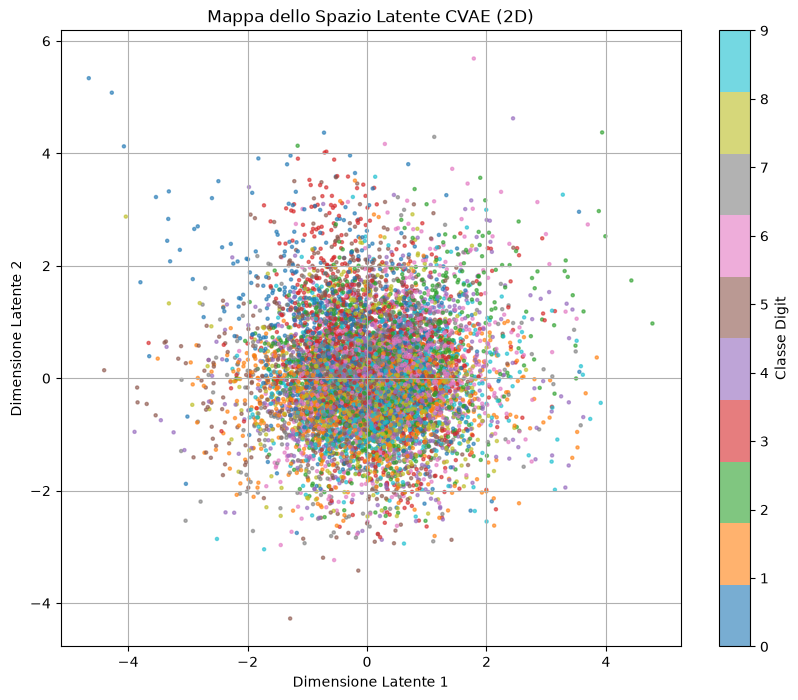

Generazione condizionata per ogni cifra...


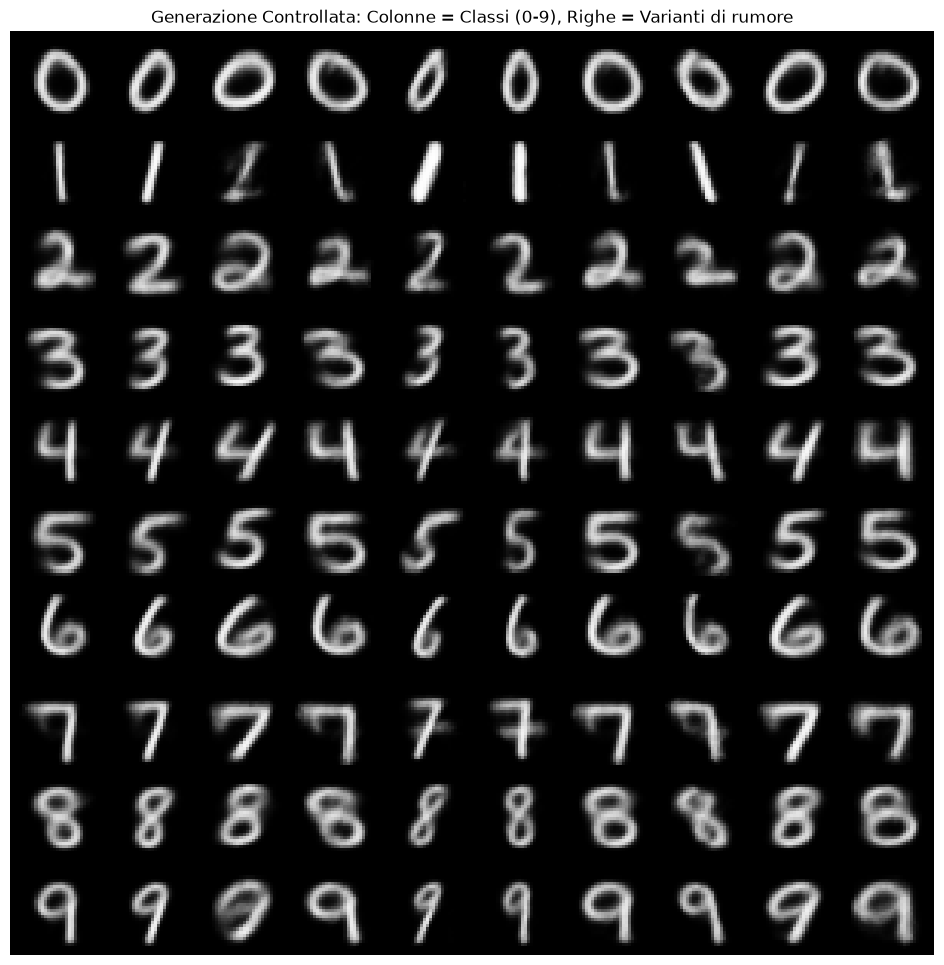

: 

In [ ]:
#CVAE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configurazione dei parametri principali per l'esecuzione del modello
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 2  # Dimensione ridotta dello spazio latente per facilitare la visualizzazione (2D)
batch_size = 128 # Numero di campioni processati in ogni iterazione
epochs = 15     # Numero di cicli completi di addestramento sul dataset
lr = 1e-3       # Tasso di apprendimento per l'ottimizzatore Adam

# Definizione della pipeline di trasformazione dei dati: conversione in tensore di PyTorch
transform = transforms.Compose([transforms.ToTensor()])

# Caricamento del dataset MNIST (cifre scritte a mano) per addestramento e test
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform), 
    batch_size=batch_size, 
    shuffle=True
)
test_loader = DataLoader(
    datasets.MNIST('.', train=False, transform=transform), 
    batch_size=1000, 
    shuffle=False
)

def to_one_hot(labels, num_classes=10):
    """
    Converte i numeri delle classi in vettori binari (one-hot encoding).
    Questa operazione è fondamentale nel CVAE per fornire al modello l'informazione 
    sulla classe specifica come input aggiuntivo (condizione).
    """
    return torch.eye(num_classes).to(device)[labels]

class CVAE(nn.Module):
    """
    Architettura del Conditional Variational Autoencoder (CVAE).
    A differenza di un VAE standard, il CVAE riceve la classe (label) sia 
    nella fase di codifica che in quella di decodifica, permettendo di 
    controllare quale specifica cifra generare.
    """
    def __init__(self, feature_dim=784, class_dim=10, latent_dim=2):
        super().__init__()
        
        # ENCODER: Riceve in input l'immagine spianata (784 pixel) concatenata alla label (10)
        # La concatenazione permette all'encoder di apprendere una distribuzione latente 
        # specifica per ogni classe.
        self.enc_fc = nn.Sequential(
            nn.Linear(feature_dim + class_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )
        # Strati lineari per estrarre i parametri della distribuzione Gaussiana
        self.fc_mu = nn.Linear(200, latent_dim)      # Media dello spazio latente
        self.fc_logvar = nn.Linear(200, latent_dim)  # Logaritmo della varianza

        # DECODER: Riceve in input il vettore latente (2) concatenato alla label (10)
        # La label funge da "guida" per ricostruire correttamente la cifra desiderata.
        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim + class_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, feature_dim),
            nn.Sigmoid() # Restituisce valori tra 0 e 1 come i pixel originali
        )

    def reparameterize(self, mu, logvar):
        """
        Applica il Reparameterization Trick.
        Invece di campionare direttamente dalla distribuzione (operazione non differenziabile),
        campioniamo un rumore casuale epsilon e lo scaliamo. Ciò permette il passaggio del gradiente.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        """
        Flusso dei dati nel modello:
        1. Prepara l'input concatenando immagine (x) e condizione (c).
        2. L'encoder estrae i parametri mu e logvar.
        3. Viene generato il vettore latente z tramite riparametrizzazione.
        4. Il decoder ricostruisce l'immagine partendo da z e dalla condizione c.
        """
        # Appiattimento dell'immagine e unione con la label
        x_cond = torch.cat([x.view(-1, 784), c], dim=1)
        h = self.enc_fc(x_cond)
        
        # Estrazione dei parametri distribuzionali
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        # Campionamento nello spazio latente
        z = self.reparameterize(mu, logvar)
        
        # Unione dello spazio latente con la label per la decodifica
        z_cond = torch.cat([z, c], dim=1)
        return self.dec_fc(z_cond), mu, logvar

# Inizializzazione del modello e dell'ottimizzatore
model = CVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

def loss_function(recon_x, x, mu, logvar):
    """
    Calcola la perdita totale del CVAE composta da due parti:
    1. BCE: Errore di ricostruzione (quanto l'output è simile all'input).
    2. KLD: Divergenza di Kullback-Leibler (regolarizza lo spazio latente verso una Gaussiana standard).
    """
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Ciclo di addestramento
print("Inizio addestramento del modello...")
model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        # Conversione delle etichette in vettori one-hot
        one_hot_labels = to_one_hot(labels)
        
        optimizer.zero_grad() # Reset dei gradienti
        # Passaggio avanti nel modello (forward pass)
        recon, mu, logvar = model(data, one_hot_labels)
        # Calcolo della perdita e backpropagation
        loss = loss_function(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    # Stampa del progresso ogni 5 epoche
    if (epoch+1) % 5 == 0:
        print(f"Epoca {epoch+1}, Perdita Media: {total_loss/len(train_loader.dataset):.2f}")

# Visualizzazione 1: Analisi della distribuzione nello spazio latente
# Mostriamo come il modello raggruppa le varie cifre nel piano 2D
model.eval()
z_list, label_list = [], []
with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        oh = to_one_hot(labels)
        # Passaggio manuale dall'encoder per ottenere la media (mu) dello spazio latente
        combined_input = torch.cat([data.view(-1, 784), oh], dim=1)
        h = model.enc_fc(combined_input)
        mu = model.fc_mu(h)
        z_list.append(mu.cpu().numpy())
        label_list.append(labels.cpu().numpy())

# Unione di tutti i risultati per il plot
z_all = np.concatenate(z_list)
labels_all = np.concatenate(label_list)

plt.figure(figsize=(10, 8))
plt.scatter(z_all[:, 0], z_all[:, 1], c=labels_all, cmap='tab10', alpha=0.6, s=5)
plt.colorbar(label="Classe Digit")
plt.title("Mappa dello Spazio Latente CVAE (2D)")
plt.xlabel("Dimensione Latente 1")
plt.ylabel("Dimensione Latente 2")
plt.grid(True)
plt.show()

# Visualizzazione 2: Generazione controllata di immagini
# Dimostrazione di come la condizione (label) influenzi l'output del decoder
print("Generazione condizionata per ogni cifra...")
with torch.no_grad():
    # Creiamo un set fisso di rumore z che verrà riutilizzato per ogni cifra
    # In questo modo verifichiamo che i cambiamenti siano dovuti solo alla label
    z_fixed = torch.randn(10, latent_dim).to(device) 
    
    all_generated = []
    for i in range(10): # Iterazione per ogni classe (da 0 a 9)
        # Creiamo un vettore di label tutte uguali alla classe corrente
        label = torch.full((10,), i, dtype=torch.long).to(device)
        oh = to_one_hot(label)
        # Il decoder genera l'immagine partendo dal rumore e dalla label specifica
        gen_imgs = model.dec_fc(torch.cat([z_fixed, oh], dim=1)).cpu()
        all_generated.append(gen_imgs.view(10, 1, 28, 28))

    # Creazione di una griglia per visualizzare i risultati
    grid_img = utils.make_grid(torch.cat(all_generated), nrow=10)
    plt.figure(figsize=(12, 12))
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title("Generazione Controllata: Colonne = Classi (0-9), Righe = Varianti di rumore")
    plt.axis('off')
    plt.show()